# Visualization Demo

This notebook demonstrates the Phase 1.5 visualization utilities using the existing classical portfolio pipeline. It keeps calculations inside the backend modules and uses the notebook only to orchestrate the workflow and display figures.

## 1. Setup

Add the project root to `sys.path` so the notebook can run from the `notebooks/` folder, then import the backend functions used in the demo.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.analysis.visualization import (
    plot_allocation_bar,
    plot_correlation_heatmap,
    plot_efficient_frontier,
    plot_price_history,
)
from backend.classical.efficient_frontier import generate_efficient_frontier
from backend.classical.markowitz import optimize_portfolio
from backend.data.covariance import compute_covariance_matrix
from backend.data.market_data import fetch_price_data
from backend.data.returns import compute_annualized_returns, compute_daily_returns

pd.options.display.float_format = "{:.4f}".format

## 2. Define Tickers

The demo uses a compact ETF universe covering broad U.S. equities, growth equities, dividend growth equities, long-term Treasuries, and gold.

In [2]:
tickers = ["SPY", "QQQ", "VIG", "TLT", "GLD"]
tickers

['SPY', 'QQQ', 'VIG', 'TLT', 'GLD']

## 3. Run the Classical Pipeline

Fetch prices, compute returns and covariance, optimize a Markowitz portfolio, and generate the efficient frontier. Each calculation delegates to an existing backend function.

In [3]:
prices = fetch_price_data(tickers, period="5y")
daily_returns = compute_daily_returns(prices)
expected_returns = compute_annualized_returns(daily_returns)
covariance_matrix = compute_covariance_matrix(daily_returns)

weights = optimize_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_aversion=1.0,
)

frontier = generate_efficient_frontier(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    num_points=50,
)

prices.head()

,SPY,QQQ,VIG,TLT,GLD
Date,,,,,
2021-05-03,390.5917,326.2489,140.5179,117.7490,167.8100
2021-05-04,388.1820,320.3779,140.7184,118.5481,166.5800
2021-05-05,388.3034,319.3007,140.8278,118.7436,167.2700
2021-05-06,391.4042,321.7073,142.0310,118.9391,170.0600
2021-05-07,394.2528,324.3178,142.7967,118.3525,171.5900


## 4. Price History

The price history plot is a first sanity check on the market data. It helps reveal whether each asset loaded correctly and how the assets moved over the selected historical window.

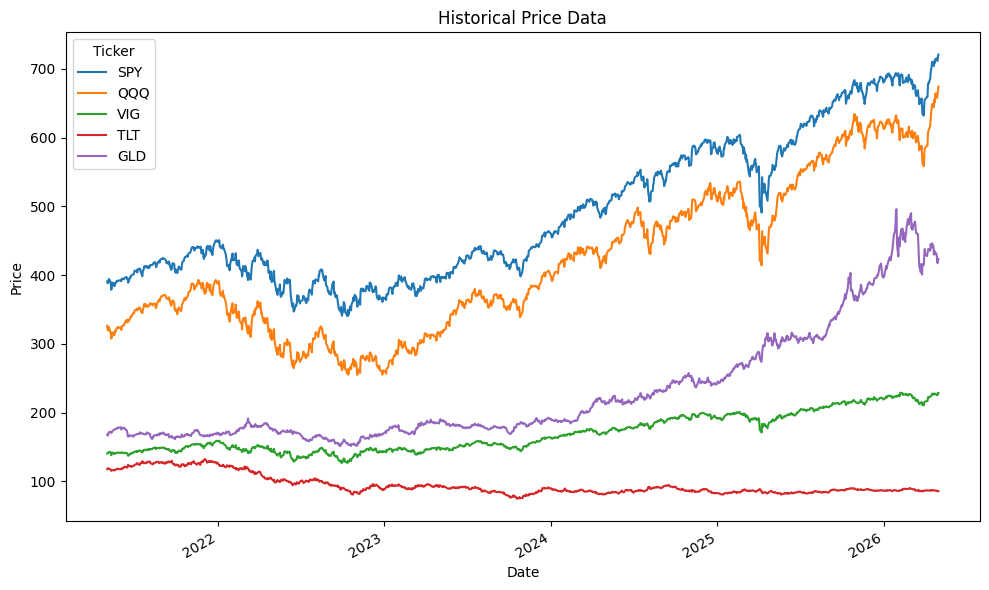

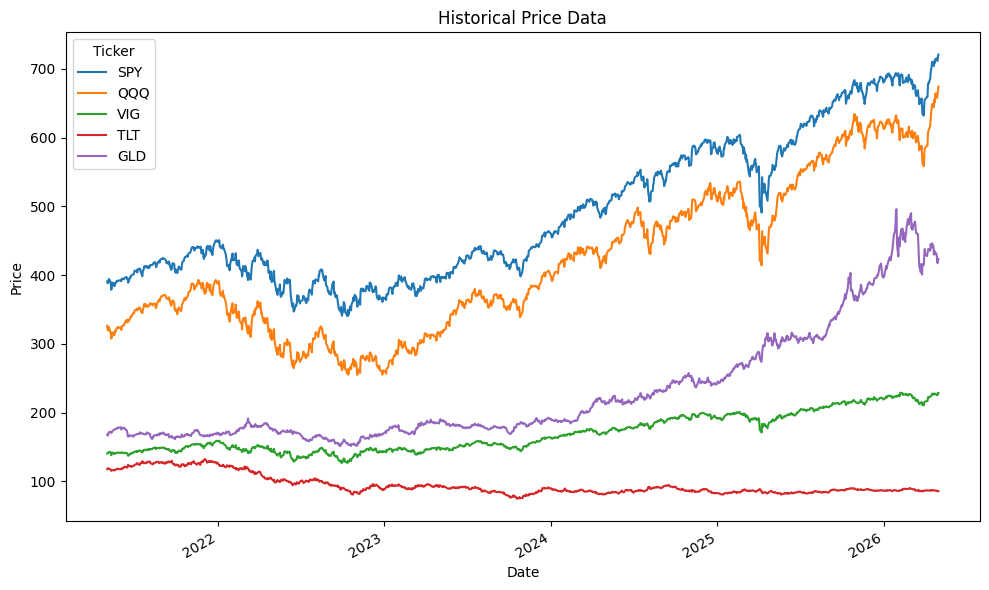

In [4]:
plot_price_history(prices)

## 5. Correlation Heatmap

The correlation heatmap shows how assets move together on a standardized scale. It is especially useful for spotting diversification relationships across the asset universe.

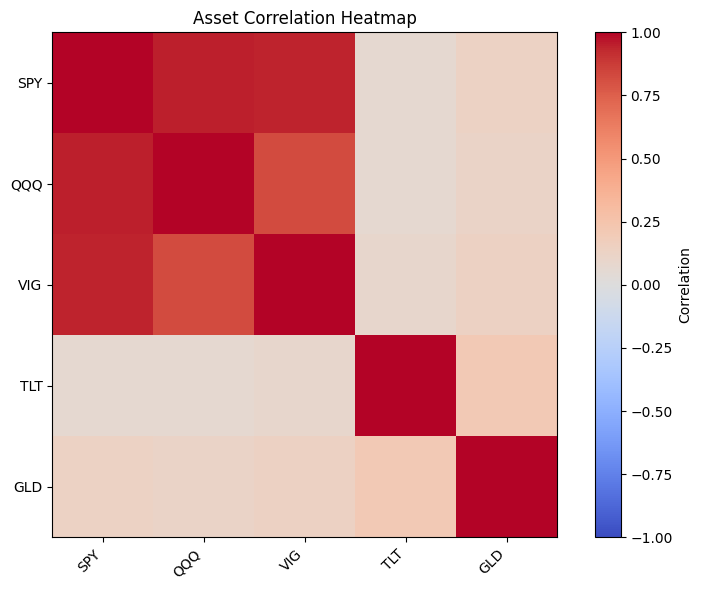

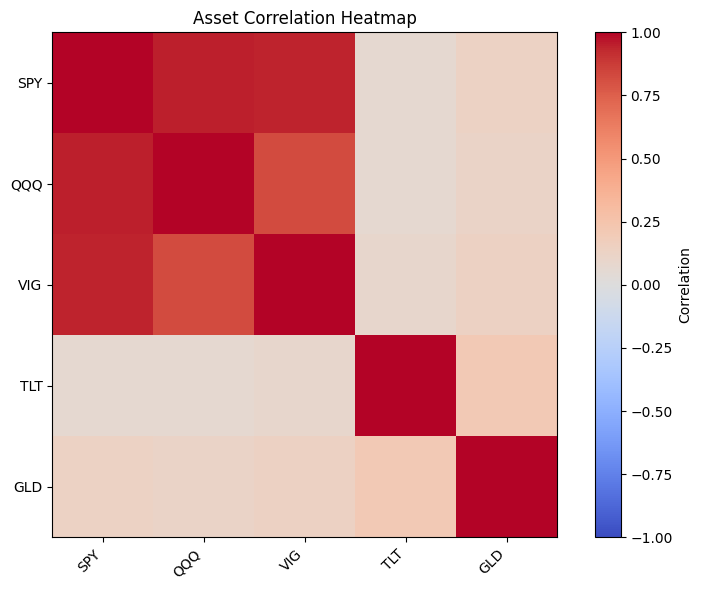

In [5]:
correlation_matrix = daily_returns.corr()
plot_correlation_heatmap(correlation_matrix)

## 6. Optimized Allocation

The allocation chart shows the optimized long-only portfolio weights. It makes the optimizer's output easy to inspect at a glance.

In [6]:
weights.to_frame("optimized_weight")

,optimized_weight
SPY,0.0000
QQQ,0.1618
VIG,0.0000
TLT,0.0000
GLD,0.8382


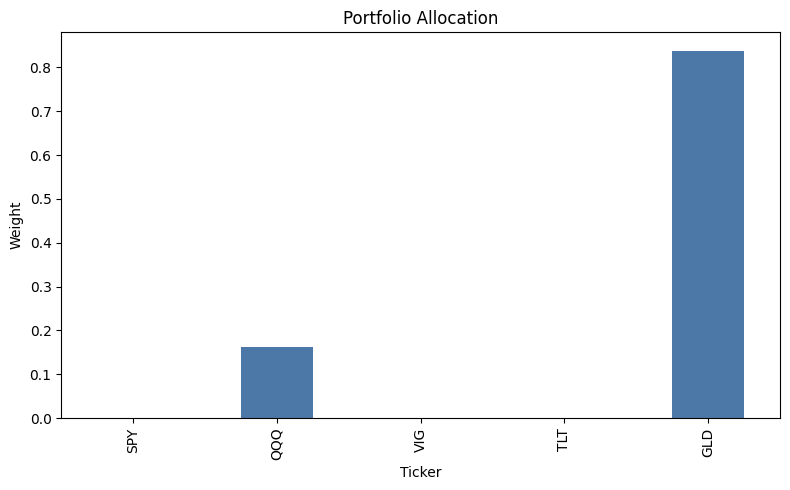

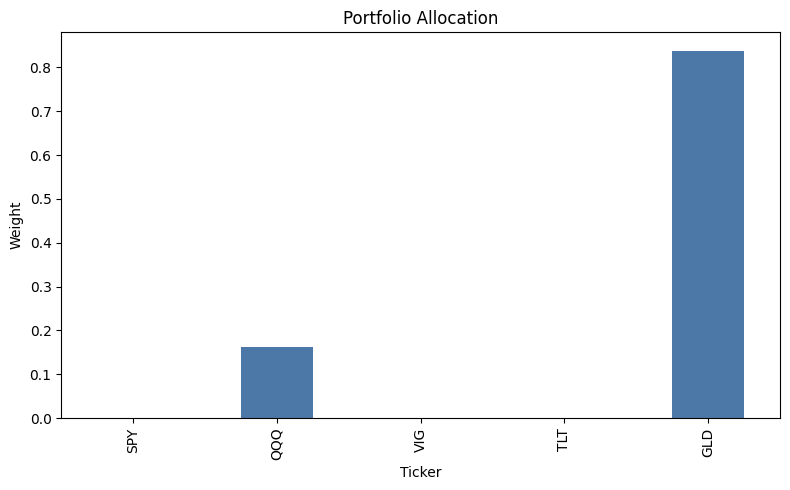

In [7]:
plot_allocation_bar(weights)

## 7. Efficient Frontier

The efficient frontier plot shows the tradeoff between expected return and volatility across many optimized portfolios. Color indicates Sharpe ratio, which helps identify portfolios with stronger return per unit of risk.

In [8]:
frontier[["target_return", "expected_return", "volatility", "sharpe_ratio"]].head()

,target_return,expected_return,volatility,sharpe_ratio
0,-0.0514,0.0760,0.1029,0.7387
1,-0.0463,0.0760,0.1029,0.7387
2,-0.0411,0.0760,0.1029,0.7387
3,-0.0359,0.0760,0.1029,0.7387
4,-0.0308,0.0760,0.1029,0.7387


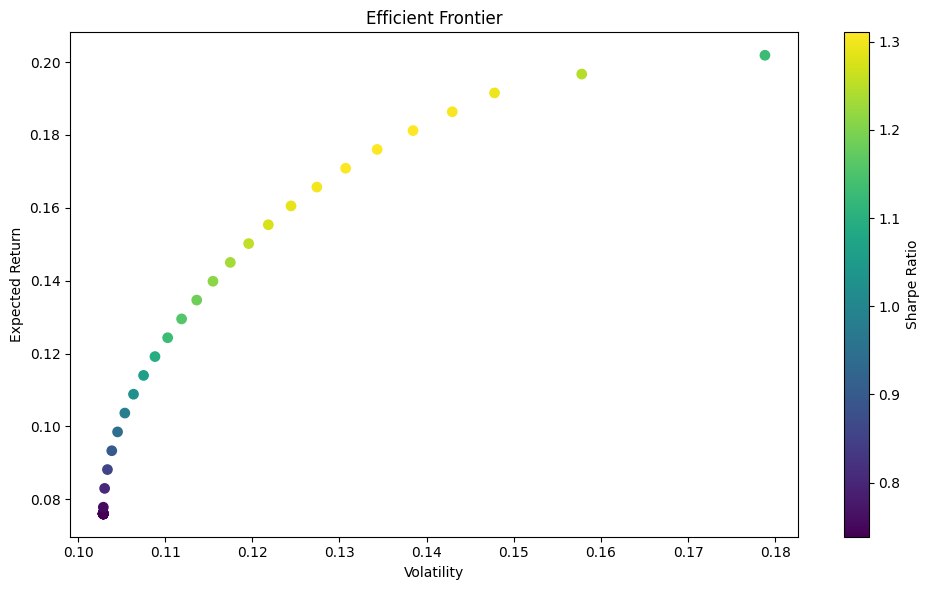

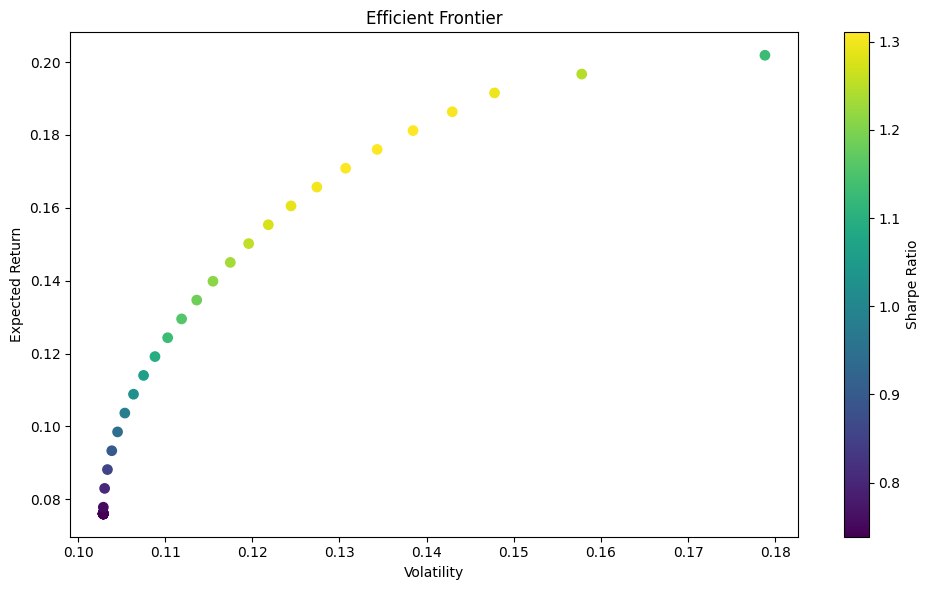

In [9]:
plot_efficient_frontier(frontier)